# Image Compression with K-means Clustering

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from random import sample
import scipy.misc
import matplotlib.cm as cm
from scipy import linalg
import imageio

## 1: Implementing K-means

### 1.1: Finding closest centroids

In [ ]:
datafile = 'data.mat' # call the MATLAB file path
mat = scipy.io.loadmat( datafile )
X = mat['X']

In [ ]:
X

In [ ]:
#Choose the number of centroids... K = 3
K = 3
initial_centroids = np.array([[3,3],[6,2],[8,5]]) # example initial value of centroids

In [ ]:
# Visualizing the data, please don't change the code below!
def plotData(myX,mycentroids,myidxs = None):
    """
    Fucntion to plot the data and color it accordingly.
    myidxs should be the latest iteraction index vector
    mycentroids should be a vector of centroids, one per iteration
    """
    
    colors = ['b','g','gold','darkorange','salmon','olivedrab']
    
    assert myX[0].shape == mycentroids[0][0].shape
    assert mycentroids[-1].shape[0] <= len(colors)

    #If idxs is supplied, divide up X into colors
    if myidxs is not None:
        assert myidxs.shape[0] == myX.shape[0]
        subX = []
        for x in range(mycentroids[0].shape[0]):
            subX.append(np.array([myX[i] for i in range(myX.shape[0]) if myidxs[i] == x]))
    else:
        subX = [myX]
        
    fig = plt.figure(figsize=(7,5))
    for x in range(len(subX)):
        newX = subX[x]
        plt.plot(newX[:,0],newX[:,1],'o',color=colors[x],
                 alpha=0.75, label='Data Points: Cluster %d'%x)
    plt.xlabel('x1',fontsize=14)
    plt.ylabel('x2',fontsize=14)
    plt.title('Plot of X Points',fontsize=16)
    plt.grid(True)

    #Drawing a history of centroid movement
    tempx, tempy = [], []
    for mycentroid in mycentroids:
        tempx.append(mycentroid[:,0])
        tempy.append(mycentroid[:,1])
    
    for x in range(len(tempx[0])):
        plt.plot(tempx, tempy, 'rx--', markersize=8)

    leg = plt.legend(loc=4, framealpha=0.5)

In [ ]:
plotData(X,[initial_centroids])

In [ ]:
def distSquared(point1, point2):
    # this function should return the squared distance between two points
    return np.sum((point2 - point1)**2)

In [ ]:
def findClosestCentroids(myX, mycentroids):
    """
    Function takes in the (m,n) X matrix
    (where m is the # of points, n is # of features per point)
    and the (K,n) centroid seed matrix
    (where K is the # of centroids (clusters)
    and returns a (m,1) vector of cluster indices 
    per point in X (0 through K-1)
    """
    idxs = np.zeros((myX.shape[0],1))
    
    #Loop through each data point in X
    for x in range(idxs.shape[0]):
        # Write code here
        
        #Then compare this point to each centroid,
        #Keep track of shortest distance and index of shortest distance
        mindist, idx = 9999999, 0
        for i in range(mycentroids.shape[0]):
            # Write code here
            distance = distSquared(myX[x], mycentroids[i])
            if distance < mindist:
                mindist = distance
                idx = i
        idxs[x] = idx

        #With the best index found, modify the result idx vector
        # Write code here
        
    return idxs

In [ ]:
idxs = findClosestCentroids(X,initial_centroids)

#you should see the output [1 3 2] corresponding to the centroid assignments for the first 3 examples.


# print indices here (Hint: output should be [0 2 1])
print(idxs[:3])

In [ ]:
plotData(X,[initial_centroids],idxs)

### 1.2: Computing centroid means

In [ ]:
i1 = 0
i2 = 0
i3 = 0
for i in range(300):
    if idxs[i] == 0:
        i1 += 1
    elif idxs[i] == 1:
        i2 += 1
    else:
        i3 += 1
i1,i2,i3

In [ ]:
def computeCentroids(myX, myidxs):
    """
    Function takes in the X matrix and the index vector
    and computes a new centroid matrix.
    """
    
    # Write code here
    # ==========================================================
    # Initial implementation (manual implementation using loops)
    # ==========================================================
    # K = int(np.max(myidxs) + 1)

    # cluster = [[] for _ in range(K)]

    # for k in range(K):
    #     for j in range(myidxs.shape[0]):
    #         if myidxs[j] == k:
    #             cluster[k].append(myX[j])

    # centroids = np.zeros((K, myX.shape[1]))
    # for k in range(K):
    #     x = 0
    #     y = 0
    #     for j in range(len(cluster[k])):
    #         x += cluster[k][j][0]
    #         y += cluster[k][j][1]

    #     centroids[k][0] = x / len(cluster[k])
    #     centroids[k][1] = y / len(cluster[k])

    # return centroids


    # ==========================================================
    # Improved implementation using NumPy functions
    # ==========================================================

    K = int(np.max(myidxs) + 1)
    n = myX.shape[1]
    centroids = np.zeros((K, n))
    for k in range(K):
        points = myX[(myidxs.flatten()) == k]
        centroids[k] = np.mean(points, axis=0)

    return centroids

## 2: K-means on example dataset

In [ ]:
def runKMeans(myX, initial_centroids, K, n_iter):
    centroid_history = []
    current_centroids = initial_centroids
    for myiter in range(n_iter):
        idxs = findClosestCentroids(myX, current_centroids)
        current_centroids = computeCentroids(myX, idxs)
        centroid_history.append(current_centroids.copy())
        
    return idxs, centroid_history

In [ ]:
idxs, centroid_history = runKMeans(X,initial_centroids, 3, 10)

In [ ]:
plotData(X,centroid_history,idxs)

## 3: Random initialization

In [ ]:
def chooseKRandomCentroids(myX, K):
    rand_indices = sample(range(0,myX.shape[0]),K)
    return np.array([myX[i] for i in rand_indices])

In [ ]:
#Let's choose random initial centroids and see the resulting 
for x in range(3):
    init_centroid = chooseKRandomCentroids(X,K)
    idxs, centroid_history = runKMeans(X,init_centroid, K, 10)
    plotData(X, centroid_history,idxs)

## 4: Image compression with K-means

### 4.1: K-means on pixels

In [ ]:
datafile = 'data.mat' 

# This creates a three-dimensional matrix A whose first two indices 
# identify a pixel position and whose last index represents red, green, or blue.
A = imageio.imread("img.jpg")

print("A shape is ", A.shape)
dummy = plt.imshow(A)

In [ ]:
# Divide every entry in A by 255 so all values are in the range of 0 to 1
# Unroll the image to shape (16384,3) (16384 is 128*128)

A = A.reshape(128*128,3)

# Run k-means on this data, forming 16 clusters, with random initialization
myK = 16
init_centroid = chooseKRandomCentroids(A,myK)
idxs, centroid_history = runKMeans(A,init_centroid,myK,10)

In [ ]:
# Now I have 16 centroids, each representing a color.
# Let's assign an index to each pixel in the original image dictating
# which of the 16 colors it should be
centroid_history
idxs = findClosestCentroids(A, centroid_history[-1])


In [182]:



final_centroids = centroid_history[-1]
# Now loop through the original image and form a new image
# that only has 16 colors in it
final_image = np.zeros((idxs.shape[0],3))
for x in range(final_image.shape[0]):
    final_image[x] = final_centroids[int(idxs[x,0])]

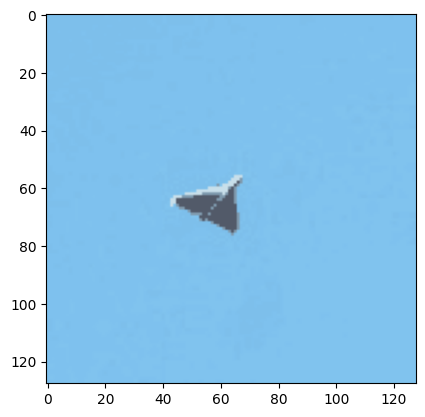

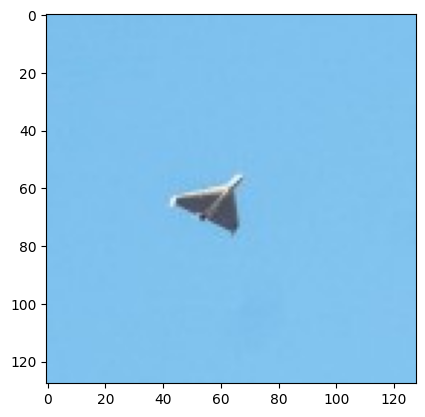

In [183]:
# Reshape the original image and the new, final image and draw them
plt.figure()
plt.imshow(final_image.reshape(128, 128, 3).astype(np.uint8))

plt.figure()
plt.imshow(A.reshape(128, 128, 3).astype(np.uint8))

plt.show()

In [ ]:
img = final_image.reshape(128, 128, 3)

print(img.shape)
print(img.dtype)

plt.imshow(img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [82.0..238.67932489451476].


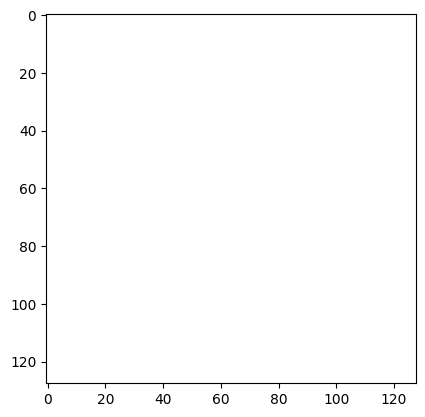

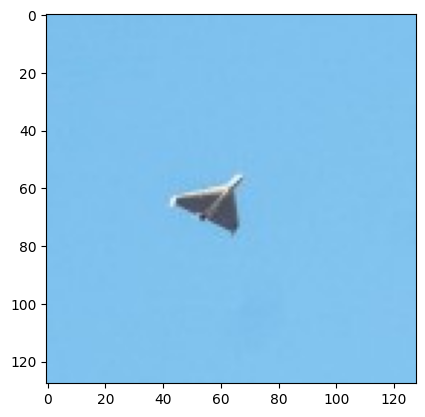

In [180]:
plt.figure()
plt.imshow(final_image.reshape(128, 128, 3))

plt.figure()
plt.imshow(A.reshape(128, 128, 3))

plt.show()